# lumina_io tutorial

`lumina_io` loads LUMINA simulation output through a Python API on top of a
parallel C++ HDF5 reader. This notebook runs on the 005 Lumina tree on MIT
ORCD (Engaging): sections 1-10 walk through the particle/catalog API on the
repackaged 500cMpc snapshots, sections 11-13 cover the gridded data products
(cartesian grids, lightcones, black hole outputs).

**Requirements:** an environment with `numpy`, `h5py`, `matplotlib`
(e.g. `source activate chii`); `hdf5plugin` for the blosc2-compressed grid
fields. Build the C++ core once with `./build.sh` -- on Engaging:
`module load community-modules` and point `HDF5_PREFIX` at the serial
hdf5/1.14.2 (see the README). The pure-h5py fallback works without it, just
slower.

**Memory note:** the 500cMpc run has $2.1\times10^{11}$ gas cells -- a single
full-box gas field is ~850 GB. Use slices, batched loads, or the chunked
iterators (section 7); never load a full particle field.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, '..')   # or: pip install -e <repo root>

import lumina_io as lumina

# the repackaged 500cMpc snapshots/catalogs on MIT ORCD (Engaging); the raw
# run on OLCF lives at /lustre/orion/ast211/proj-shared/arsmith/500cMpc and
# works identically
basePath = '/orcd/data/mvogelsb/005/Lumina/Lumina_above_z_4p75'
print('C++ core available:', lumina.HAVE_CORE)

C++ core available: True


## 1. Discovering what exists

`basePath` can be the run directory (auto-descends into `output_subfind/`),
the output directory itself, or -- as here -- an 005 epoch directory whose
`snapshots/` and `group_files/` subdirs are searched transparently. Every
field is its own HDF5 file on disk; the helpers below tell you what is
available without opening anything large.

In [2]:
print('snapshots with group catalogs:', lumina.util.listSnaps(basePath, 'Group'))
print('snapshots with gas fields:    ', lumina.util.listSnaps(basePath, 'PartType0'))
print()
print('gas fields:    ', lumina.util.listFields(basePath, 'PartType0', 116))
print()
print('star fields:   ', lumina.util.listFields(basePath, 'PartType4', 116))

snapshots with group catalogs: [48, 57, 66, 74, 80, 97, 102, 106, 116]
snapshots with gas fields:     [24, 36, 48, 57, 66, 74, 86, 97, 102, 106, 116]

gas fields:     ['Density', 'GFM_Metallicity', 'HII_Fraction', 'HeIII_Fraction', 'HeII_Fraction', 'IntCoordinates', 'InternalEnergy', 'Masses', 'ParticleIDs', 'PhotonDensity', 'StarFormationRate', 'Velocities']

star fields:    ['GFM_InitialMass', 'GFM_Metallicity', 'GFM_StellarFormationTime', 'IntCoordinates', 'Masses', 'ParticleIDs', 'Velocities']


In [3]:
snap = 116   # z = 5

header = lumina.snapshot.loadHeader(basePath, snap)
print('z = %.3f,  a = %.4f,  BoxSize = %g ckpc/h' % (
    header['Redshift'], header['Time'], header['BoxSize']))
print('NumPart_Total:', header['NumPart_Total'])

cat_header = lumina.groupcat.loadHeader(basePath, snap)
print('Ngroups = %d,  Nsubhalos = %d' % (cat_header['Ngroups_Total'], cat_header['Nsubhalos_Total']))

cosmo = lumina.units.getCosmology(basePath)
print('h = %g, Omega0 = %g, OmegaBaryon = %g' % (
    cosmo['HubbleParam'], cosmo['Omega0'], cosmo['OmegaBaryon']))

z = 5.000,  a = 0.1667,  BoxSize = 338300 ckpc/h
NumPart_Total: [212925386222 216000000000            0            0    529104789
       564081]
Ngroups = 261879169,  Nsubhalos = 247410469
h = 0.6766, Omega0 = 0.309641, OmegaBaryon = 0.0489747


## 2. Group catalog

Conventions: a list of fields returns a dict with a
`'count'` key; a single field name returns the bare array. Fields are read in
parallel across files. Pass `units='comoving'` or `'physical'` to convert from
code units (section 6).

In [4]:
halos = lumina.groupcat.loadHalos(basePath, snap, ['GroupMass', 'GroupPos', 'GroupLenType'])
print('loaded %d halos' % halos['count'])
print('GroupPos:', halos['GroupPos'].shape, halos['GroupPos'].dtype)

mstar = lumina.groupcat.loadSubhalos(basePath, snap, 'SubhaloMassType')[:, 4]  # bare array
print('subhalos with stars: %d' % (mstar > 0).sum())

loaded 261879169 halos
GroupPos: (261879169, 3) float32


subhalos with stars: 37290115


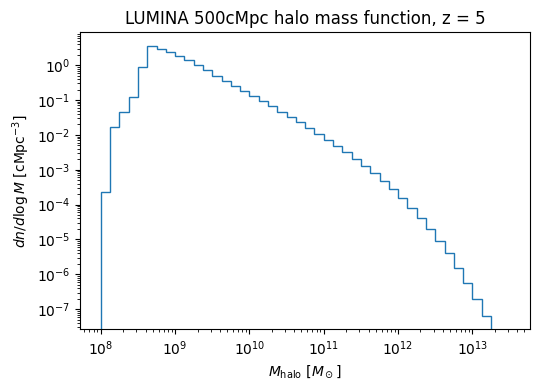

In [5]:
# halo mass function at z=5
m = lumina.units.convert(halos['GroupMass'], 'GroupMass', basePath, snap)  # -> Msun
bins = np.logspace(8, 13.5, 45)
boxsize_cmpc = header['BoxSize'] / cosmo['HubbleParam'] / 1e3     # comoving Mpc
counts, edges = np.histogram(m[m > 0], bins=bins)
dlogm = np.diff(np.log10(edges))

plt.figure(figsize=(5.5, 4))
plt.stairs(counts / dlogm / boxsize_cmpc**3, edges)
plt.loglog(); plt.xlabel(r'$M_{\rm halo}\ [M_\odot]$')
plt.ylabel(r'$dn/d\log M\ [{\rm cMpc}^{-3}]$')
plt.title('LUMINA 500cMpc halo mass function, z = 5')
plt.tight_layout(); plt.show()

In [6]:
# everything the catalog knows about one object
halo0 = lumina.groupcat.loadSingle(basePath, snap, haloID=0)
print('most massive halo: M = %.3g x 1e10 Msun/h, %d subhalos, LenType = %s'
      % (halo0['GroupMass'], halo0['GroupNsubs'], halo0['GroupLenType']))

most massive halo: M = 945 x 1e10 Msun/h, 137 subhalos, LenType = [303916 620010      0      0 227713      7]


## 3. Particles of a single halo / subhalo

`loadHalo` / `loadSubhalo` slice the snapshot-global particle arrays using the
offsets stored *inside* the catalog (`GroupOffsetType` / `SubhaloOffsetType` --
the new LUMINA location, instead of TNG's `postprocessing/offsets`).

`'Coordinates'` is an alias: positions are stored as `IntCoordinates` (uint32
fractions of the box); the alias converts to float64 ckpc/h in parallel C++.

227713 star particles, total M* = 8.26e+11 Msun


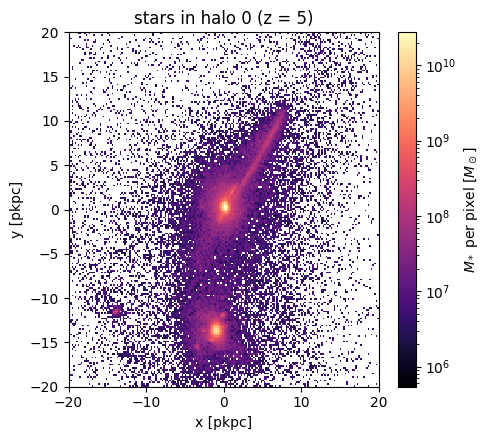

In [7]:
haloID = 0
stars = lumina.snapshot.loadHalo(basePath, snap, haloID, 'stars',
                                 ['Coordinates', 'Masses', 'GFM_StellarFormationTime'],
                                 units='physical')   # kpc, Msun
print('%d star particles, total M* = %.3g Msun' % (stars['count'], stars['Masses'].sum()))

x, y = stars['Coordinates'][:, 0], stars['Coordinates'][:, 1]
cx, cy = np.median(x), np.median(y)
plt.figure(figsize=(5, 4.5))
plt.hist2d(x - cx, y - cy, bins=200, range=[[-20, 20], [-20, 20]],
           weights=stars['Masses'], norm='log', cmap='magma')
plt.xlabel('x [pkpc]'); plt.ylabel('y [pkpc]')
plt.title('stars in halo %d (z = 5)' % haloID)
plt.colorbar(label=r'$M_*$ per pixel $[M_\odot]$')
plt.tight_layout(); plt.show()

In [8]:
# gas of a subhalo, in code units this time
sub = lumina.groupcat.loadSingle(basePath, snap, haloID=haloID)
sid = int(sub['GroupFirstSub'])
gas = lumina.snapshot.loadSubhalo(basePath, snap, sid, 'gas', ['Density', 'Masses'])
print('central subhalo %d: %d gas cells' % (sid, gas['count']))

central subhalo 0: 274061 gas cells


## 4. Batched loading -- many halos at once

Looping `loadHalo` over thousands of objects pays per-call metadata costs.
`snapshot.loadHalos` (plural) gathers all offsets at once and reads every halo's
particles in a few large parallel passes (~6x faster cold). Fields come back
concatenated in `ids` order with a `'lens'` array for splitting.

In [9]:
lens = lumina.groupcat.loadHalos(basePath, snap, 'GroupLenType')
ids = np.where(lens[:, 4] > 30000)[0][:100]          # 100 star-rich halos

batch = lumina.snapshot.loadHalos(basePath, snap, ids, 'stars',
                                  ['Masses', 'Velocities'], units='physical')
print('%d halos, %d particles total' % (len(ids), batch['count']))

# per-halo arrays via np.split
per_halo_masses = np.split(batch['Masses'], np.cumsum(batch['lens'])[:-1])
mstar = np.array([m.sum() for m in per_halo_masses])
print('median M* of the sample: %.3g Msun' % np.median(mstar))

100 halos, 6612237 particles total


median M* of the sample: 2.1e+11 Msun


## 5. Arbitrary slices

`loadSubset` reads any `[start, start+count)` window of the snapshot-global
arrays -- useful with the offsets from `getSnapOffsets`, or for sampling.
`mdi` selects one column of a vector field at read level.

In [10]:
off = lumina.snapshot.getSnapOffsets(basePath, snap, haloID, 'Group')
print('halo %d offsets per type:' % haloID, off['offsetType'], 'lens:', off['lenType'])

vy = lumina.snapshot.loadSubset(basePath, snap, 'stars', ['Velocities'],
                                subset={'start': 0, 'count': 1_000_000}, mdi=[1])
print('y-velocities of the first 1M star particles:', vy['Velocities'].shape, vy['Velocities'].dtype)

halo 0 offsets per type: [0 0 0 0 0 0] lens: [303916 620010      0      0 227713      7]
y-velocities of the first 1M star particles: (1000000,) float16


## 6. Units

Code units (per [lumina-simulation.com/data-access](https://lumina-simulation.com/data-access)):
lengths in ckpc/h, masses in $10^{10}\,M_\odot/h$, particle velocities stored
such that peculiar velocity $= v \sqrt{a}$, `GroupVel` peculiar $= v/a$
(conventions verified against the team's `disk_analysis` code).

Every loader accepts `units=`:

| target | meaning |
|---|---|
| `'code'` | as stored (default) |
| `'comoving'` | h and $10^{10}$ factors removed; velocities made peculiar |
| `'physical'` | scale-factor factors applied too (kpc, $M_\odot$/kpc$^3$, ...) |

Dimensionless fields, IDs, counts, SFR, temperatures pass through untouched.

In [11]:
from lumina_io import units

for field in ['GroupPos', 'GroupMass', 'Density', 'Velocities', 'GroupVel', 'SubhaloSpin']:
    print('%-12s code: %-32s physical: %s' % (
        field, units.fieldUnits(field, 'code'), units.fieldUnits(field, 'physical')))

a = units.getScaleFactor(basePath, snap)
print('\nconversion factor for Density at a=%.4f: %.4g' % (
    a, units.conversionFactor('Density', 'physical', basePath=basePath, snapNum=snap)))

GroupPos     code: ckpc/h                           physical: kpc
GroupMass    code: 1e10 Msun/h                      physical: Msun
Density      code: 1e10 Msun/h/(ckpc/h)^3           physical: Msun/kpc^3
Velocities   code: km/s / sqrt(a)                   physical: km/s (peculiar)
GroupVel     code: km/s / a                         physical: km/s (peculiar)
SubhaloSpin  code: (kpc/h)(km/s)                    physical: kpc km/s

conversion factor for Density at a=0.1667: 9.888e+11


## 7. Chunked iteration -- larger-than-memory loops

Never load a full particle field of this box. `iterSubset` (and
`groupcat.iterHalos` / `iterSubhalos`) yield consecutive `chunkSize`-row windows;
while you process one chunk the next is already being read in the background.
Two chunks at most are ever in memory.

In [12]:
# total stellar mass of the box, never holding more than ~400 MB
total = 0.0
nchunks = 0
for chunk in lumina.snapshot.iterSubset(basePath, snap, 'stars', 'Masses',
                                        chunkSize=100_000_000):
    total += chunk['Masses'].astype(np.float64).sum()
    nchunks += 1
h = float(cosmo['HubbleParam'])
print('%d chunks -> total M* = %.4g Msun' % (nchunks, total * 1e10 / h))

6 chunks -> total M* = 2.043e+15 Msun


In [13]:
# catalogs too: peak of the halo mass histogram without loading 79 fields
hist = np.zeros(45)
for chunk in lumina.groupcat.iterHalos(basePath, snap, 'GroupMass', chunkSize=50_000_000):
    hist += np.histogram(chunk['GroupMass'], bins=np.logspace(-4, 3.5, 46))[0]
print('histogram from %s halos' % int(hist.sum()))

histogram from 261879169 halos


## 8. Performance knobs and the low-level core

The C++ core resolves HDF5 chunk addresses once, then bypasses libhdf5 with many
concurrent `pread()` calls (the data is chunked but uncompressed). Tuning:

- `lumina.set_num_threads(n)` or env `LUMINA_NTHREADS` (default min(cores, 16));
- multi-field loads already overlap across files via a thread pool;
- Lustre detail (measured on the OLCF copy; striping differs per filesystem):
  the first 128 GB of each file sits on a single OST (~2 GB/s ceiling); beyond
  that files are striped over 8 OSTs and threads pay off (~8 GB/s measured).

The raw primitives are available directly:

In [14]:
from lumina_io import _core, util

path, dset = util.fieldPath(basePath, 'Group', 'GroupPos', snap)
print(_core.dataset_info(path, dset))

import time
t0 = time.time()
pos = _core.read(path, dset, 0, 50_000_000, 16)     # 50M rows, 16 threads
print('read %.2f GB in %.2f s' % (pos.nbytes / 1e9, time.time() - t0))

# many ranges in one parallel pass (what batched loadHalos uses)
parts = _core.read_multi(path, dset, np.array([0, 10**6, 10**8]), np.array([2, 2, 2]))
print(parts)

{'shape': (261879169, 3), 'dtype': '<f4', 'layout': 'chunked', 'nfilters': 0, 'chunks': (2097152, 3)}


read 0.60 GB in 0.42 s
[[175298.02   57957.93  265728.28 ]
 [304777.7   202361.23  333620.16 ]
 [150488.95  286032.2   330045.72 ]
 [215297.52    2342.333  28783.78 ]
 [292429.53   72911.47  255532.7  ]
 [294461.     75664.12  183272.06 ]]


## 9. Derived fields

`Temperature` [K], `ElectronAbundance`, `MeanMolecularWeight`, `SoundSpeed` [km/s],
`NeutralHydrogenFraction`, and `StellarAge` [Myr] are computed on the fly in any
snapshot loader -- the raw inputs (InternalEnergy, ionization fractions, ...) are
read automatically and the outputs are already physical (unaffected by `units=`).

halo 0 gas: median T = 1.47e+07 K
stars: median age 129 Myr (9296 wind particles -> NaN)


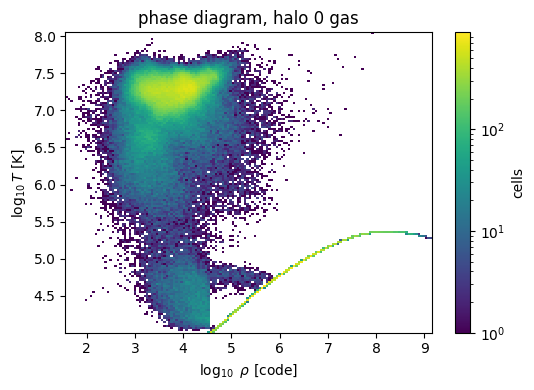

In [15]:
gas = lumina.snapshot.loadHalo(basePath, snap, haloID, 'gas',
                               ['Temperature', 'Density', 'Masses'])
print('halo %d gas: median T = %.3g K' % (haloID, np.median(gas['Temperature'])))

ages = lumina.snapshot.loadHalo(basePath, snap, haloID, 'stars', 'StellarAge')
print('stars: median age %.0f Myr (%d wind particles -> NaN)'
      % (np.nanmedian(ages), np.isnan(ages).sum()))

plt.figure(figsize=(5.5, 4))
plt.hist2d(np.log10(gas['Density'] * 1e10), np.log10(gas['Temperature']),
           bins=150, norm='log', cmap='viridis')
plt.xlabel(r'$\log_{10}\ \rho$ [code]'); plt.ylabel(r'$\log_{10} T$ [K]')
plt.title('phase diagram, halo %d gas' % haloID)
plt.colorbar(label='cells'); plt.tight_layout(); plt.show()

## 10. 3D cartesian grids (`lumina.grid`)
The gridded data products live in the same 005 tree, one level up from the
epoch directories. The cartesian grids (`3d_cartesian_grid/ren_<N>`) hold
~30 fields rendered to N³ cells (N = 5 ... 2560) per snapshot. Snapshots
0-428 live in the `Lumina_above_z_4p75` epoch tree and 429-708 in
`Lumina_below_z_4p75`; pass the root and the right epoch is picked per
snapshot.

`region=` cuts periodic sub-volumes (pixel ranges or center/size in code
units) reading only the file chunks the cut touches. `units='cgs'` converts
to physical cgs using the per-dataset scaling attributes stored on disk
(`to_cgs * a^a_scaling * h^h_scaling`; float64 output).

In [17]:
root = '/orcd/data/mvogelsb/005/Lumina'

print('resolutions:', lumina.grid.listResolutions(root))
snaps = lumina.grid.listSnaps(root, res=640)
print('snapshots:  %d ... %d (%d total)' % (snaps[0], snaps[-1], len(snaps)))

gsnap = 270   # z = 6.78: the reionization midpoint (the box is ~53% ionized)
ghdr = lumina.grid.loadHeader(root, gsnap, res=640)
print('snap %d: z = %.3f, %d^3 cells, cell size %.1f ckpc/h'
      % (gsnap, ghdr['Redshift'], ghdr['NumPixels'],
         ghdr['BoxSize'] / ghdr['NumPixels']))
print(lumina.grid.listFields(root, gsnap, res=640))

resolutions: [5, 10, 20, 40, 80, 160, 320, 640, 1280, 2560]
snapshots:  0 ... 708 (709 total)
snap 270: z = 6.780, 640^3 cells, cell size 528.6 ckpc/h
['Density', 'DensityDM', 'DensityMetals', 'DensityStars', 'HII_Fraction', 'HII_VolumeFraction', 'HeIII_Fraction', 'HeIII_VolumeFraction', 'HeII_Fraction', 'HeII_VolumeFraction', 'IonEnergies', 'IonEnergy', 'IonFlux', 'IonLuminosityStars', 'LuminosityAGN', 'LyaLuminosityCol', 'LyaLuminosityRec', 'SpectralDensity', 'SpectralDensityHI', 'SpectralIonLuminosityStars', 'SpectralLuminosityAGN', 'SpectralLyaLuminosityCol', 'SpectralLyaLuminosityRec', 'SpectralStarFormationRate', 'SpectralTemperature', 'StarFormationRate', 'Temperature', 'TemperatureVolumeWeighted', 'Velocities', 'VelocitySquared', 'Volume']


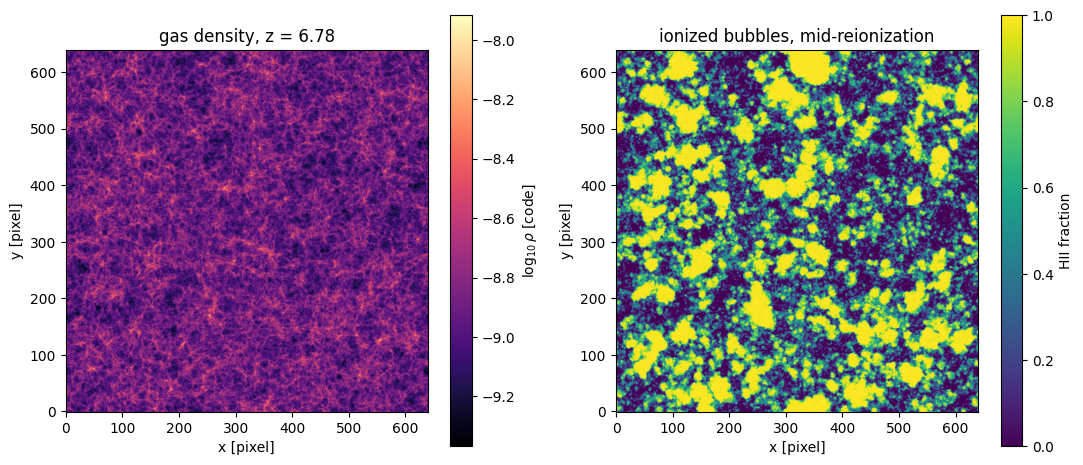

In [18]:
# a 10-cell-thick slab at 640^3 -- only the file chunks touching the region
# are read (regions are periodic: negative / wrapping pixel ranges are fine).
# At the z=6.78 midpoint the ionized-bubble structure is at its patchiest.
slab = lumina.grid.loadGrid(root, gsnap, ['Density', 'HII_Fraction'], res=640,
                            region=((0, 640), (0, 640), (315, 325)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
im = axes[0].imshow(np.log10(slab['Density'].mean(axis=2)).T, origin='lower',
                    cmap='magma')
plt.colorbar(im, ax=axes[0], label=r'$\log_{10}\rho$ [code]')
axes[0].set_title('gas density, z = %.2f' % ghdr['Redshift'])
im = axes[1].imshow(slab['HII_Fraction'].mean(axis=2).T, origin='lower',
                    vmin=0, vmax=1, cmap='viridis')
plt.colorbar(im, ax=axes[1], label='HII fraction')
axes[1].set_title('ionized bubbles, mid-reionization')
for ax in axes:
    ax.set_xlabel('x [pixel]'); ax.set_ylabel('y [pixel]')
plt.tight_layout(); plt.show()

In [19]:
# physical-cgs sub-cube around the densest cell of a coarse grid; region
# dicts take center/size in code units (ckpc/h), pixel tuples work too
rho160 = lumina.grid.loadGrid(root, gsnap, 'Density', res=160)
i, j, k = np.unravel_index(np.argmax(rho160), rho160.shape)
cell = ghdr['BoxSize'] / 160
cut = lumina.grid.loadGrid(root, gsnap, 'Density', res=640, units='cgs',
                           region={'center': ((i + .5) * cell, (j + .5) * cell,
                                              (k + .5) * cell),
                                   'size': 4000.})
print('cut %s around the densest coarse cell: max rho = %.3e g/cm^3'
      % (cut.shape, cut.max()))

# chunked iteration for grids that do not fit in memory (67 GB at 2560^3):
# volume-weighted mean temperature, slab by slab
num = den = 0.0
for c in lumina.grid.iterGrid(root, gsnap, ['Temperature', 'Volume'], res=160,
                              chunkSize=40):
    num += (c['Temperature'] * c['Volume']).sum(dtype=np.float64)
    den += c['Volume'].sum(dtype=np.float64)
print('volume-weighted <T> = %.0f K at z = %.2f' % (num / den, ghdr['Redshift']))

cut (8, 8, 8) around the densest coarse cell: max rho = 1.239e-26 g/cm^3
volume-weighted <T> = 11012 K at z = 6.78


## 11. Lightcones (`lumina.lightcone`)
`lightcone/rlc_<N>` holds the same fields rendered onto a lightcone: an
angular (N, N) grid transverse, the line of sight **last**, ordered far →
near. The two epoch trees are segments of **one** lightcone
(z = 30 → 4.75 → 2.99) sharing the boundary edge; given the root they are
stitched into a single global LOS index space.

Cut along the LOS with `zRange` (redshift), `dRange` (comoving distance) or
`losRange` (cell indices), and transversely with `region=((x0,x1),(y0,y1))`;
only the file chunks touching the cut are read (one 2560² field is 198 GB).
Every cut returns its own `Redshifts`/`Distances` cell edges. `units='cgs'`
applies a per-cell scale factor along the LOS for a-dependent fields.

5896 LOS cells stitched from segments of [4010, 1886], z = 30.0 -> 2.99
opening angle: 3.60 deg, 640^2 transverse pixels


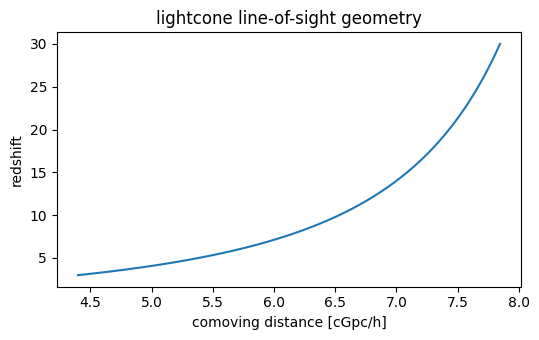

In [20]:
co = lumina.lightcone.losCoordinates(root, res=640)
lhdr = lumina.lightcone.loadHeader(root, res=640)
print('%d LOS cells stitched from segments of %s, z = %.1f -> %.2f'
      % (co['NumDepth'], [int(n) for n in lhdr['SegmentNumDepth']],
         co['Redshifts'][0], co['Redshifts'][-1]))
print('opening angle: %.2f deg, %d^2 transverse pixels'
      % (np.degrees(lhdr['OpeningAngle']), lhdr['NumPixels']))

plt.figure(figsize=(5.5, 3.5))
plt.plot(co['Distances'][:-1] / 1e6, co['Redshifts'][:-1])
plt.xlabel('comoving distance [cGpc/h]'); plt.ylabel('redshift')
plt.title('lightcone line-of-sight geometry')
plt.tight_layout(); plt.show()

cut shape: (640, 640, 296)  losRange: (2993, 3289)


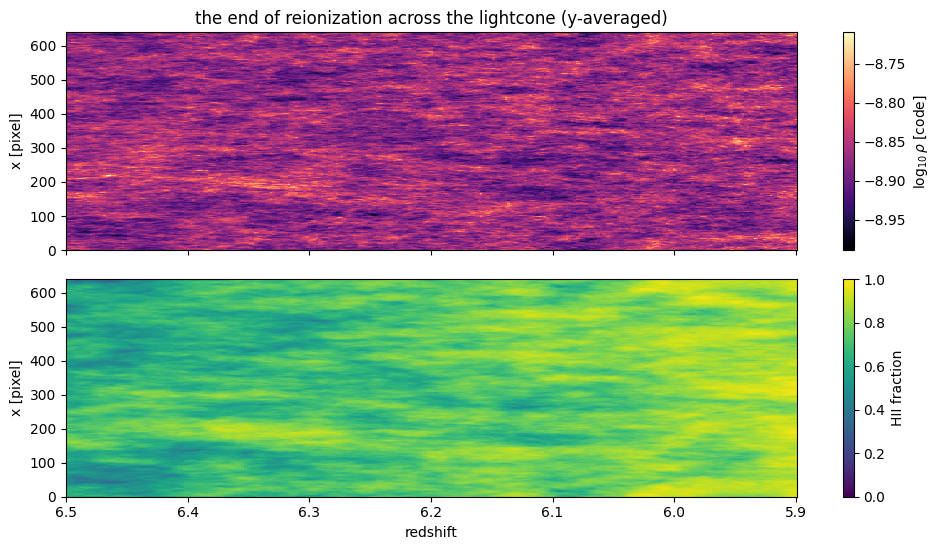

In [21]:
# a redshift slab: all transverse pixels, cells overlapping 5.9 < z < 6.5
# (~1 GB for two fields at this width). Cuts crossing the z=4.75 epoch
# boundary work the same way -- the stitching is transparent.
cut = lumina.lightcone.loadLightcone(root, ['Density', 'HII_Fraction'],
                                     res=640, zRange=(5.9, 6.5), sq=False)
print('cut shape:', cut['Density'].shape, ' losRange:', cut['losRange'])

fig, axes = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True)
im = axes[0].pcolormesh(cut['Redshifts'], np.arange(641),
                        np.log10(cut['Density'].mean(axis=1)), cmap='magma')
plt.colorbar(im, ax=axes[0], label=r'$\log_{10}\rho$ [code]')
im = axes[1].pcolormesh(cut['Redshifts'], np.arange(641),
                        cut['HII_Fraction'].mean(axis=1), vmin=0, vmax=1)
plt.colorbar(im, ax=axes[1], label='HII fraction')
axes[1].set_xlabel('redshift'); axes[1].invert_xaxis()
for ax in axes:
    ax.set_ylabel('x [pixel]')
axes[0].set_title('the end of reionization across the lightcone (y-averaged)')
plt.tight_layout(); plt.show()

## 12. Black holes (`lumina.bh`)
`Lumina_combined_outputs` carries high-cadence outputs of the **full BH
population** (910 outputs spanning z = 14.3 → 3.0, with their own
0307...1216 counter -- not the snapshot numbering) and a merger catalog.

`trackBH` follows one ParticleID through time (range pruned with the
precomputed `bh_lifetimes` table; epochs where the BH does not exist come
back NaN). **Caveat:** at a BH-BH merger the surviving ParticleID is often
the *lighter* partner's, so a massive BH's ID typically appeared late and
jumped by orders of magnitude in one event -- tracking the ID is not
tracking the growing object. `trackMainProgenitor` fixes this by walking
the merger catalog backwards and switching to the most massive victim's ID
at each such event. Fields share names with PartType5, so
`units='comoving'/'physical'` work as usual (each output converted with its
own scale factor).

1979351 BHs at z = 2.99


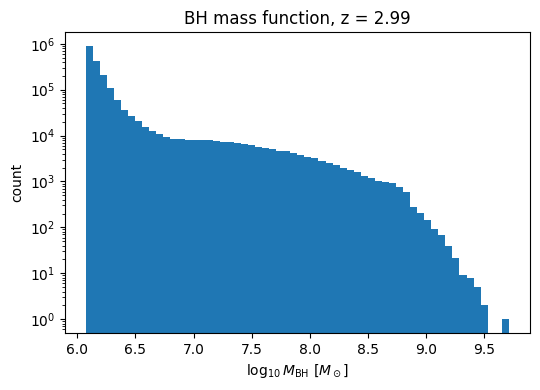

In [22]:
last = lumina.bh.listSnaps(root)[-1]
bhs = lumina.bh.loadSnap(root, last, ['BH_Mass', 'BH_Mdot'], units='physical',
                         sq=False)
print('%d BHs at z = %.2f' % (bhs['count'], bhs['Redshift']))

plt.figure(figsize=(5.5, 4))
plt.hist(np.log10(bhs['BH_Mass'][bhs['BH_Mass'] > 0]), bins=60)
plt.yscale('log'); plt.xlabel(r'$\log_{10} M_{\rm BH}\ [M_\odot]$')
plt.ylabel('count'); plt.title('BH mass function, z = %.2f' % bhs['Redshift'])
plt.tight_layout(); plt.show()

chain of 8 IDs, outputs 524-1216 (z = 9.1 -> 3.0)


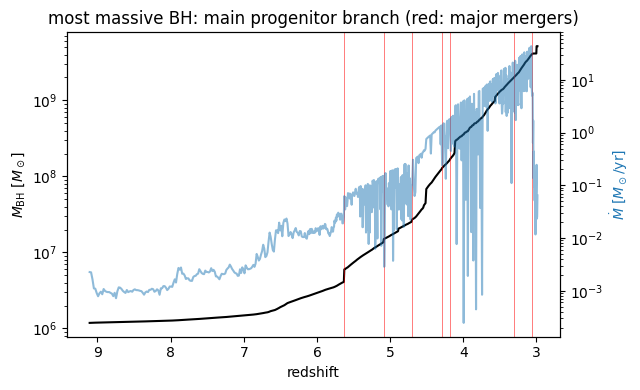

In [23]:
# growth history of the most massive BH along its main progenitor branch.
# Its final ParticleID only appeared at output 1028 and acquired nearly all
# of its mass in one merger -- the main-progenitor walk stitches the time
# series across 7 such ID changes, back to the output where the line of
# most massive progenitors was seeded.
ids = lumina.bh.loadSnap(root, last, 'ParticleIDs')
bigID = int(ids[np.argmax(bhs['BH_Mass'])])

tr = lumina.bh.trackMainProgenitor(root, bigID, ['BH_Mass', 'BH_Mdot'],
                                   units='physical')
print('chain of %d IDs, outputs %d-%d (z = %.1f -> %.1f)'
      % (len(tr['chain']), tr['snaps'][0], tr['snaps'][-1],
         tr['Redshift'][0], tr['Redshift'][-1]))

fig, ax1 = plt.subplots(figsize=(6.5, 4))
ax1.plot(tr['Redshift'], tr['BH_Mass'], 'k-')
ax1.set_xlabel('redshift'); ax1.set_ylabel(r'$M_{\rm BH}\ [M_\odot]$')
ax1.invert_xaxis(); ax1.set_yscale('log')
ax2 = ax1.twinx()
ax2.plot(tr['Redshift'], tr['BH_Mdot'], 'C0-', alpha=.5)
ax2.set_yscale('log'); ax2.set_ylabel(r'$\dot M\ [M_\odot/{\rm yr}]$', color='C0')
for w in np.flatnonzero(np.diff(tr['ids']) != 0) + 1:   # ID-changing mergers
    ax1.axvline(tr['Redshift'][w], color='r', lw=.6, alpha=.6)
ax1.set_title('most massive BH: main progenitor branch (red: major mergers)')
plt.tight_layout(); plt.show()